In [1]:
from torchvision import datasets, transforms

train_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.96MB/s]


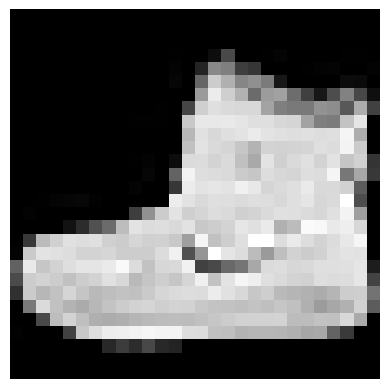

Label nombor: 9


In [5]:
import matplotlib.pyplot as plt

image, label = train_data[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.axis('off')
plt.show()

print("Label nombor:", label)

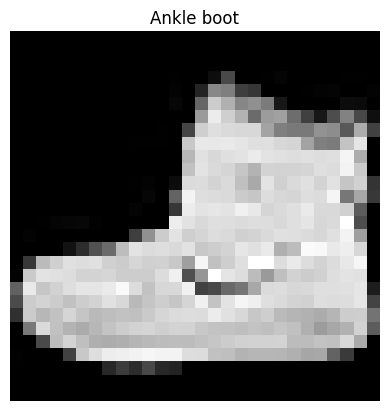

Label nombor:  9
Nama objek:  Ankle boot


In [7]:
import matplotlib.pyplot as plt
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

image, label = train_data[0]
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis("off")
plt.show()

print("Label nombor: ", label)
print("Nama objek: ", class_names[label])

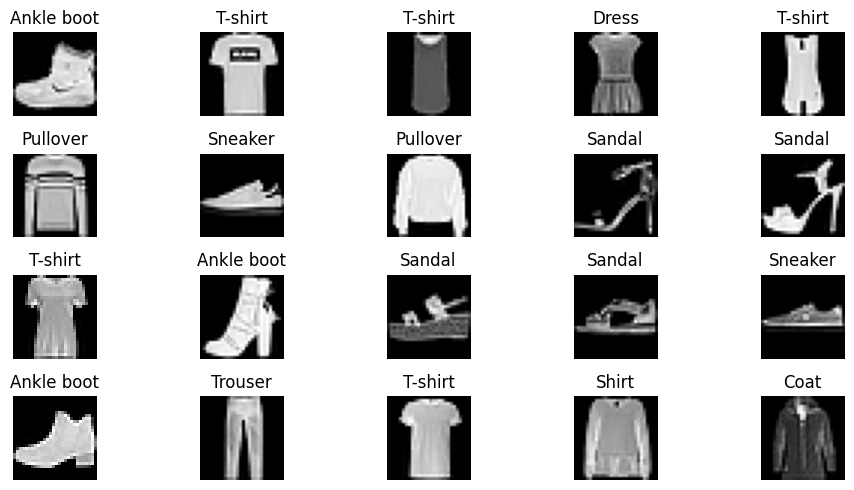

In [13]:
import matplotlib.pyplot as plt

class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(20):
    image, label = train_data[i]

    plt.subplot(4, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

        self.fc = nn.Linear(
            16 * 14 * 14,
            10
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x


model = SimpleCNN()

print(model)

SimpleCNN(
  (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)
